In [1]:
from scMM.file.data import CyESIData
#data = CyESIData.load_from_file("/home/zby/scMM/data/P-1.mzML",
 #                               ref_mz = 760.5839, cell_snr = 5.0, peak_snr = 2.0)

In [2]:
data = CyESIData("/home/zby/scMM/data/wochong/p-2").normalize()

In [3]:
from scMM.plot.engine import PlotEngine
eg = PlotEngine.from_adata(data.to_anndata(), fig_path_dir="/home/zby/scMM/data/wochong/res")

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/zby/miniconda3/envs/scMM/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
eg.pca(n_components=100)
eg.umap(use_pca=True, n_neighbors=20, min_dist=0.7)

/home/zby/miniconda3/envs/scMM/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


array([[ 9.796286 ,  4.443656 ],
       [13.876898 ,  6.5172563],
       [ 9.284057 ,  5.122255 ],
       [10.894517 ,  4.486368 ],
       [13.963986 ,  9.5556   ],
       [ 9.837906 ,  4.158452 ],
       [ 8.843709 ,  6.149356 ],
       [14.50347  ,  7.6167483],
       [14.868857 ,  6.988917 ],
       [14.319064 ,  5.387172 ],
       [16.031921 ,  6.893984 ],
       [13.821802 , 10.710039 ],
       [10.26618  ,  4.4573803],
       [ 9.7579565,  5.143488 ],
       [13.903115 ,  4.819275 ],
       [12.195763 ,  8.028917 ],
       [13.230608 ,  5.7745614],
       [14.657139 ,  4.9202104],
       [11.719865 ,  3.5692103],
       [16.8193   ,  7.1201077],
       [ 9.492732 ,  4.5749564],
       [ 9.315358 ,  5.4060607],
       [11.4581995,  5.044542 ],
       [ 8.909886 ,  4.9543037],
       [13.2620535, 10.143436 ],
       [14.273211 , 11.26525  ],
       [10.477001 ,  4.5080395],
       [16.117641 ,  7.68574  ],
       [ 9.820688 ,  6.813254 ],
       [10.078342 ,  4.0202236],
       [10

In [11]:
eg.cluster_cells(method="leiden", n_neighbors=20, resolution=1.0, key_added="leiden_cluster", s=20)

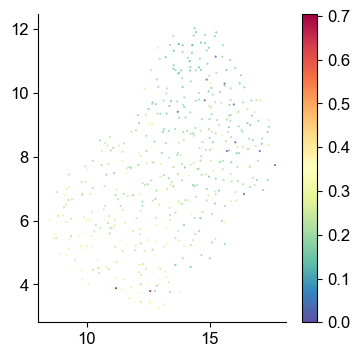

In [15]:
import matplotlib.pyplot as plt
X = eg.adata.obsm["X_umap"]
plt.scatter(X[:,0], X[:,1], c=data[768.5903]/data[774.6377], s=0.2)
plt.colorbar()
plt.savefig("/home/zby/scMM/data/wochong/res/768.5903.svg", dpi=300)

In [7]:
eg.compute_trajectory(step_size = 20, parameterization_key="time", plotting=True)

In [8]:
eg.plot_metabolite_trends(step_size=20, parameterization_key="time", plot_top_n=50, feature_name_key="mz")

In [9]:
eg.plot_trend_clusters()